In [ ]:
import torch
from torch.autograd import Variable

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
print(torch.cuda.is_available())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

True
cuda:0


In [ ]:
def plot_forward(net,conductivity=None,heat_source=None):

    x=np.arange(0,2,0.02)
    t=np.arange(0,1,0.02)
    ms_x, ms_t = np.meshgrid(x, t)
    x_all = np.ravel(ms_x).reshape(-1,1)
    t_all = np.ravel(ms_t).reshape(-1,1)
    pt_x = Variable(torch.from_numpy(x_all).float(), requires_grad=False).to(device)
    pt_t = Variable(torch.from_numpy(t_all).float(), requires_grad=False).to(device)

    if heat_source is not None:

      pt_u = heat_source(pt_x,pt_t)
      u=pt_u.data.cpu().numpy()
      ms_u = u.reshape(ms_x.shape)

      fig = plt.figure()
      ax = fig.add_subplot(projection = '3d')

      surf = ax.plot_surface(ms_x,ms_t,ms_u, cmap=cm.coolwarm,linewidth=0, antialiased=False)
      fig.colorbar(surf, shrink=0.4, aspect=5)
      plt.xlabel('x')
      plt.ylabel('t')
      plt.title('heat source q(x,t)')
      plt.show()

    fig = plt.figure()
    ax = fig.add_subplot(projection = '3d')

    pt_u = net(pt_x,pt_t)
    u=pt_u.data.cpu().numpy()
    ms_u = u.reshape(ms_x.shape)

    surf = ax.plot_surface(ms_x,ms_t,ms_u, cmap=cm.coolwarm,linewidth=0, antialiased=False)
    fig.colorbar(surf, shrink=0.4, aspect=5)
    plt.xlabel('x')
    plt.ylabel('t')
    plt.title('temperature u(x,t)')
    plt.show()



    if conductivity is not None:
      u = conductivity( Variable(torch.from_numpy(x).float()) )

      plt.plot(x,u,'+')
      plt.xlabel('x')
      plt.ylabel('k')
      plt.title('conductivity k(x)')
      plt.show()

**Definition du probleme de transfert de chaleur**

In [ ]:
class forward_problem:
  def __init__(self,net=None):
    #la variable net sera la fonction de regression qui approximera le champ de chaleur
    if net is not None:
      self.net = net

  def heat_source(self,x,t):
    #la valeur du terme source de chaleur q(x,t), qui peut etre dans un premier temps zero partout
    q = torch.zeros_like(x)

    return q

  def advection(self,x,t,u, beta, uref):
    #la valeur du terme d'advection
    q = beta * (u - uref)

    return q

  def conductivity(self,x):
    k=torch.ones_like(x)

    return k

  def heat_capacity(self,x):
    #la chaleur specifique qui peut varier dans le milieu; par defaut, constante et egale à 1
    c=torch.ones_like(x)

    return c

  def ic(self,x):
    #conditions initiales
    ic = torch.zeros_like(x)

    return ic

  def bc(self,x,t):
    #conditions aux limites
    bc = 1*(1 - torch.exp(-t/0.1))

    return bc

  def f(self,x,t):
    #l'estimation :
    u = self.net(x,t)

    #u_x recupere les gradients de u par rapport à x
    #torch.autograd.grad renvoie un tuple, le grad est la premiere valeur
    u_x = torch.autograd.grad(
      u, x,
      grad_outputs=torch.ones_like(u),
      retain_graph=True,
      create_graph=True
    )[0]

    flux = -1.0*self.conductivity(x) * u_x

    #faire pareil avec flux_x. Si vous le laissez à zero, pas de flux
    flux_x = torch.autograd.grad(flux, x,
                                 grad_outputs=torch.ones_like(flux),
                                 retain_graph=True,
                                 create_graph=True
                                 )[0]

    #faire pareil avec u_t
    u_t = torch.autograd.grad(
    u, t,
    grad_outputs=torch.ones_like(u),
    retain_graph=True,
    create_graph=True
)[0]

    #ecrire le  residuel pour (x,t) en fonction de l'equation diff de la chaleur
    residual = self.heat_capacity(x) * u_t - flux_x - self.heat_source(x,t) - self.advection(x,t,u,3,0)

    return residual

  #residuel conditions aux bords
  def f_bc(self,x,t):
    u = self.net(x,t)
    residual=u-self.bc(x,t)

    return residual

  #residuel conditions initiales
  def f_ic(self,x,t):
    u = self.net(x,t)
    residual=u-self.ic(x)

    return residual

  def solve(self,N_iter=1000):
    solve(self,N_iter)

  def plot_forward(self):
    plot_forward(self.net)


In [ ]:
class forward_problem:
    def __init__(self, net):
        # Store the neural network as an attribute
        self.net = net

    def heat_source(self, x, t):
        # As specified in the problem, q(x,t) = 0 initially
        q = torch.zeros_like(x)
        return q

    def advection(self, x, t, u, beta=3, uref=0):
        # Advection term as specified: β(u - uref)
        q = beta * (u - uref)
        return q

    def conductivity(self, x):
        # Simplified constant conductivity initially
        # You can modify this later to be more complex
        k = torch.ones_like(x)
        return k

    def heat_capacity(self, x):
        # Default constant heat capacity
        c = torch.ones_like(x)
        return c

    def ic(self, x):
        # Initial conditions: u(x, t=0) = 0
        ic = torch.zeros_like(x)
        return ic

    def bc(self, x, t):
        # Boundary conditions:
        # u(x=0, t) = B(1 - exp(-t/Tu)), B=1, Tu=0.1
        # u(x=L, t) = 0, L=2
        B = 1.0
        Tu = 0.1

        # Create a tensor to store boundary conditions
        bc_values = torch.where(x == 0, B * (1 - torch.exp(-t / Tu)), torch.zeros_like(x))
        return bc_values
    # Cette méthode calcule le résidu de l'équation de la chaleur:
    # ρc∂u/∂t = ∂/∂x(k∂u/∂x) - β(u-uref) + q
    # Le réseau est entraîné pour minimiser ce résidu
    def f(self, x, t):
        # Complete the residual calculation for the heat equation
        u = self.net(x, t)

        # Compute gradients
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        # Compute flux and flux_x
        flux = -1.0 * self.conductivity(x) * u_x
        flux_x = torch.autograd.grad(
            flux, x,
            grad_outputs=torch.ones_like(flux),
            retain_graph=True,
            create_graph=True
        )[0]

        # Heat equation residual
        c = self.heat_capacity(x)
        beta = 3  # Given in the problem description
        uref = 0  # Given in the problem description

        residual = c * u_t - flux_x - self.advection(x, t, u, beta, uref)

        return residual

    def f_bc(self, x, t):
        # Boundary condition residual
        u = self.net(x, t)
        residual = u - self.bc(x, t)
        return residual

    def f_ic(self, x, t):
        # Initial condition residual
        u = self.net(x, t)
        residual = u - self.ic(x)
        return residual

    def plot_forward(self, conductivity=None, heat_source=None):
        # Make sure to add the plotting method from the original code
        x = np.arange(0, 2, 0.02)
        t = np.arange(0, 1, 0.02)
        ms_x, ms_t = np.meshgrid(x, t)
        x_all = np.ravel(ms_x).reshape(-1, 1)
        t_all = np.ravel(ms_t).reshape(-1, 1)
        pt_x = Variable(torch.from_numpy(x_all).float(), requires_grad=False).to(device)
        pt_t = Variable(torch.from_numpy(t_all).float(), requires_grad=False).to(device)

        if heat_source is not None:
            pt_u = heat_source(pt_x, pt_t)
            u = pt_u.data.cpu().numpy()
            ms_u = u.reshape(ms_x.shape)

            fig = plt.figure()
            ax = fig.add_subplot(projection='3d')

            surf = ax.plot_surface(ms_x, ms_t, ms_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
            fig.colorbar(surf, shrink=0.4, aspect=5)
            plt.xlabel('x')
            plt.ylabel('t')
            plt.title('heat source q(x,t)')
            plt.show()

        fig = plt.figure()
        ax = fig.add_subplot(projection='3d')

        pt_u = self.net(pt_x, pt_t)
        u = pt_u.data.cpu().numpy()
        ms_u = u.reshape(ms_x.shape)

        surf = ax.plot_surface(ms_x, ms_t, ms_u, cmap=cm.coolwarm, linewidth=0, antialiased=False)
        fig.colorbar(surf, shrink=0.4, aspect=5)
        plt.xlabel('x')
        plt.ylabel('t')
        plt.title('temperature u(x,t)')
        plt.show()

        if conductivity is not None:
            u = conductivity(Variable(torch.from_numpy(x).float()))

            plt.plot(x, u, '+')
            plt.xlabel('x')
            plt.ylabel('k')
            plt.title('conductivity k(x)')
            plt.show()


    # Méthode principale d'entraînement du réseau
    # Utilise la méthode des résidus pour résoudre l'EDP:
    # 1. Échantillonne des points dans le domaine (points de collocation)
    # 2. Calcule le résidu de l'EDP en ces points
    # 3. Minimise ce résidu par descente de gradient
    def solve(self, N_iter=1000):
        # Add the solve method from the original code to the class
        net = self.net

        # Mean squared error loss function
        mse_cost_function = torch.nn.MSELoss()

        # Adam optimizer with learning rate and weight decay
        optimizer = torch.optim.Adam(net.parameters(), lr=1.0e-2, weight_decay=1.0e-100)

        # Échantillonnage aléatoire dans le domaine de x pour les points de collocation
        pt_x_collocation = Variable(torch.Tensor(100, 1).uniform_(0.0, 2.0), requires_grad=True).to(device)

        # Échantillonnage aléatoire dans le domaine de t pour les points de collocation
        pt_t_collocation = Variable(torch.Tensor(100, 1).uniform_(0.0, 1.0), requires_grad=True).to(device)

        # Échantillonnage aléatoire dans le domaine de x pour les conditions initiales
        pt_x_collocation_ic = Variable(torch.Tensor(100, 1).uniform_(0.0, 2.0), requires_grad=True).to(device)

        # t pour conditions initiales (toujours zéro)
        pt_t_collocation_ic = Variable(torch.zeros_like(pt_x_collocation_ic), requires_grad=True).to(device)

        # Génération des x pour les conditions aux bords (0 et 2)
        pt_x_collocation_bc = Variable(torch.tensor([[0.0], [2.0]]).float(), requires_grad=True).to(device)

        # Échantillonnage aléatoire dans le domaine de t pour les conditions aux bords
        pt_t_collocation_bc = Variable(torch.Tensor(2, 1).uniform_(0.0, 1.0), requires_grad=True).to(device)

        # Indicateur pour la randomisation des points de collocation
        randomise_colloc = 1

        # Boucle d'entraînement
        for epoch in range(N_iter):
            # Réinitialiser les gradients à zéro
            optimizer.zero_grad()

            # Randomisation des points de collocation si activée
            if randomise_colloc == 1:
                pt_x_collocation = Variable(torch.Tensor(100, 1).uniform_(0.0, 2.0), requires_grad=True).to(device)
                pt_t_collocation = Variable(torch.Tensor(100, 1).uniform_(0.0, 1.0), requires_grad=True).to(device)

                pt_x_collocation_ic = Variable(torch.Tensor(100, 1).uniform_(0.0, 2.0), requires_grad=True).to(device)
                pt_t_collocation_ic = Variable(torch.zeros_like(pt_x_collocation_ic), requires_grad=True).to(device)

                pt_x_collocation_bc = Variable(torch.tensor([[0.0], [2.0]]).float(), requires_grad=True).to(device)
                pt_t_collocation_bc = Variable(torch.Tensor(2, 1).uniform_(0.0, 1.0), requires_grad=True).to(device)

            # Calcul de la perte basée sur l'EDP
            f_out = self.f(pt_x_collocation, pt_t_collocation)
            pt_all_zeros = Variable(torch.zeros_like(f_out), requires_grad=False).to(device)
            mse_f = mse_cost_function(f_out, pt_all_zeros)

            # Calcul de la perte pour les conditions initiales
            f_out_ic = self.f_ic(pt_x_collocation_ic, pt_t_collocation_ic)
            pt_all_zeros = Variable(torch.zeros_like(f_out_ic), requires_grad=False).to(device)
            mse_ic = mse_cost_function(f_out_ic, pt_all_zeros)

            # Calcul de la perte pour les conditions aux bords
            f_out_bc = self.f_bc(pt_x_collocation_bc, pt_t_collocation_bc)
            pt_all_zeros = Variable(torch.zeros_like(f_out_bc), requires_grad=False).to(device)
            mse_bc = mse_cost_function(f_out_bc, pt_all_zeros)

            # Calcul de la perte globale
            # Vous pouvez ajuster les coefficients si nécessaire
            loss = mse_f + mse_ic + mse_bc

            # Rétropropagation
            loss.backward()

            # Mise à jour des paramètres
            optimizer.step()

            # Affichage périodique de la perte
            if epoch <= 10 or epoch == 25 or epoch == 50 or epoch % 100 == 0:
                with torch.autograd.no_grad():
                    print(epoch, "Training Loss:", loss.data)

            # Visualisation périodique
            if epoch == N_iter-1:
                self.plot_forward()

**La definition du reseau de neurones**

In [ ]:
# un reseau standard feed forward
# le choix des parametres reste toujours un probleme ouvert
class FCN(torch.nn.Module):
    def __init__(self):
      super(FCN, self).__init__()
      self.hidden_layer1 = torch.nn.Linear(2,100)
      self.hidden_layer2 = torch.nn.Linear(100,10)
      self.output_layer = torch.nn.Linear(10,1)

    def forward(self, x,t):
      inputs = torch.cat([x,t],axis=1) # on concatene pour avoir une seule variable
      layer1_out = torch.sigmoid(self.hidden_layer1(inputs))
      layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out))
      output = self.output_layer(layer2_out) ## pour une regression, pas d'activation apres la derniere couche
      return output

In [ ]:
def solve(problem,N_iter=1000):

    net = problem.net

    mse_cost_function = torch.nn.MSELoss() # Mean squared error
    optimizer = torch.optim.Adam(net.parameters(),lr=1.0e-2, weight_decay=1.0e-100)

    # echantillonage aleatoire dans le domaine de x
    pt_x_collocation = Variable(torch.Tensor(100,1).uniform_(0.0, 2.0), requires_grad=True).to(device)

    # echantillonage aleatoire dans le domaine de t
    pt_t_collocation = torch.rand(100,1, requires_grad=True).to(device) * 1.0

    # echantillonage aleatoire dans le domaine de x pour les conditions initiales
    pt_x_collocation_ic = torch.rand(100,1, requires_grad=True).to(device) * 2.0

    # t pour ic?
    pt_t_collocation_ic = torch.zeros_like(pt_x_collocation_ic).requires_grad_(True).to(device)


    # generer des x aleatoires pour les conditions aux bords
    # attention verifier les valeurs, randint a besoin de (valeur max + 1) pour generer valeur max

    # x collocation PDE
    pt_x_collocation = torch.rand(100,1, requires_grad=True).to(device) * 2.0  #  x dans [0,2]

    # t collocation PDE
    pt_t_collocation = torch.rand(100,1, requires_grad=True).to(device) * 1.0  # t dans [0,1]

    # echantillonage aleatoire dans le domaine de t
    pt_t_collocation_bc = torch.rand(100,1, requires_grad=True).to(device) * 1.0


    pt_x_collocation_bc = torch.cat([torch.zeros(50,1), 2*torch.ones(50,1)], dim=0).to(device)
    pt_x_collocation_bc.requires_grad = True
    pt_t_collocation_bc = torch.rand(100,1, requires_grad=True).to(device)
    #attention si l'echantillonage est aleatoire, il faut faire egalement ces tirages partout dans la boucle d'etntrainement

    randomise_colloc = 1
    for epoch in range(N_iter):
        optimizer.zero_grad() # to make the gradients zero

        # Loss based on PDE
        if  randomise_colloc==1:
          pt_x_collocation = torch.rand(100,1, requires_grad=True).to(device) * 2.0

          pt_t_collocation = torch.rand(100,1, requires_grad=True).to(device) * 1.0



        f_out = problem.f(pt_x_collocation, pt_t_collocation) # output of f(x,t)
        pt_all_zeros  = Variable(torch.zeros_like(f_out), requires_grad=False).to(device)
        mse_f = mse_cost_function(f_out, pt_all_zeros)


        # Loss ic
        if randomise_colloc==1:
          pt_x_collocation_ic = torch.rand(100,1, requires_grad=True).to(device) * 2.0

          pt_t_collocation_ic = torch.zeros_like(pt_x_collocation_ic).to(device)


        f_out_ic  = problem.f_ic(pt_x_collocation_ic , pt_t_collocation_ic)
        pt_all_zeros  = Variable(torch.zeros_like(f_out_ic), requires_grad=False).to(device)
        mse_ic = mse_cost_function(f_out_ic , pt_all_zeros )


        # Loss bc
        if  randomise_colloc==1:
          pt_x_collocation_bc = torch.cat([torch.zeros(50,1), 2*torch.ones(50,1)], dim=0).to(device)

          pt_x_collocation_bc.requires_grad = True

          pt_t_collocation_bc = torch.rand(100,1, requires_grad=True).to(device)


        f_out_bc = problem.f_bc(pt_x_collocation_bc , pt_t_collocation_bc) # output of f(x,t)
        pt_all_zeros  = Variable(torch.zeros_like(f_out_bc), requires_grad=False).to(device)
        mse_bc = mse_cost_function(f_out_bc , pt_all_zeros )

        # loss globale!
        loss = mse_bc+mse_f+mse_ic

        loss.backward() # calcul gradients en backprop
        optimizer.step() # equivalent à : theta_new = theta_old - alpha * derivee de J w.r.t theta

        # print loss
        if epoch<=10 or epoch==25 or epoch==50 or epoch%100==0:
          with torch.autograd.no_grad():
            print(epoch,"Traning Loss:",loss.data)


        if epoch<=10 or epoch==25 or epoch==50 or epoch==100 or epoch==250 or epoch%500==0:

          problem.plot_forward()

**La procedure d'entrainement**

**Instantiation**

<IPython.core.display.Javascript object>

0 Training Loss: tensor(0.9672, device='cuda:0')
1 Training Loss: tensor(0.5059, device='cuda:0')
2 Training Loss: tensor(0.8566, device='cuda:0')
3 Training Loss: tensor(0.7003, device='cuda:0')
4 Training Loss: tensor(0.4973, device='cuda:0')
5 Training Loss: tensor(0.5105, device='cuda:0')
6 Training Loss: tensor(0.6253, device='cuda:0')
7 Training Loss: tensor(0.2903, device='cuda:0')
8 Training Loss: tensor(0.5165, device='cuda:0')
9 Training Loss: tensor(0.4520, device='cuda:0')
10 Training Loss: tensor(0.4847, device='cuda:0')
25 Training Loss: tensor(0.0948, device='cuda:0')
50 Training Loss: tensor(0.1682, device='cuda:0')
100 Training Loss: tensor(0.3382, device='cuda:0')
200 Training Loss: tensor(0.1034, device='cuda:0')
300 Training Loss: tensor(0.0559, device='cuda:0')
400 Training Loss: tensor(0.0389, device='cuda:0')
500 Training Loss: tensor(0.0858, device='cuda:0')
600 Training Loss: tensor(0.1131, device='cuda:0')
700 Training Loss: tensor(0.0546, device='cuda:0')
800

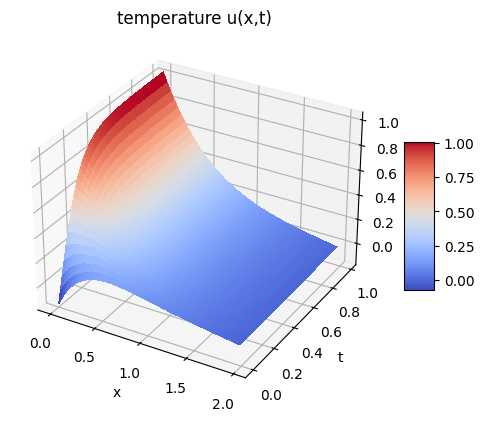

In [ ]:
net = FCN().to(device)
heat_equation = forward_problem(net)

from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 500})'''))

heat_equation.solve(N_iter=5000)